# Базовый табличный baseline — Elliptic++

Точка отсчёта всей серии: логистическая регрессия и случайный лес на 165 числовых признаках транзакции, без графа и текста. Задача ноутбука не в рекордах, а в честной нижней планке: всё, что дальше (графовые признаки, эмбеддинги, причинный фильтр), будет сравниваться с этими цифрами на том же разбиении.

Разбиение — строго по времени (train 1..30, valid 31..40, test 41..49): перемешивание подмешало бы в обучение «завтрашние» транзакции, и метрики стали бы красивыми и бесполезными.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

from _elliptic_loader import load_elliptic, temporal_split
from _theme import plot_confusion, plot_pr_curve, plot_roc_curve, setup

setup()

# resolve DATA_ROOT from notebook location (docs/notebooks -> ../../data/elliptic_raw)
candidates = [
    Path("../../data/elliptic_raw"),
    Path("../data/elliptic_raw"),
    Path("data/elliptic_raw"),
    Path.cwd() / "data/elliptic_raw",
    Path.cwd().parent.parent / "data/elliptic_raw",
]
DATA_ROOT = next((p for p in candidates if p.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError(f"Elliptic data not found, tried: {candidates}")
print(f"DATA_ROOT = {DATA_ROOT.resolve()}")


DATA_ROOT = /Users/kirill/Documents/Spillety/data/elliptic_raw


## 1. Загрузка данных
Используем `load_elliptic` — без прямого `pd.read_csv`. Проверяем размер, примеры строк и распределение классов.


features: (203769, 167)  (txId, time_step, 165 признаков)
classes:  (203769, 2)
edgelist: (234355, 2)
merged:   (203769, 168)


,txId,time_step,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,feat_166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown


class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
time_step,203769.0,23.843961,15.17217,1.0,9.0,23.0,38.0,49.0


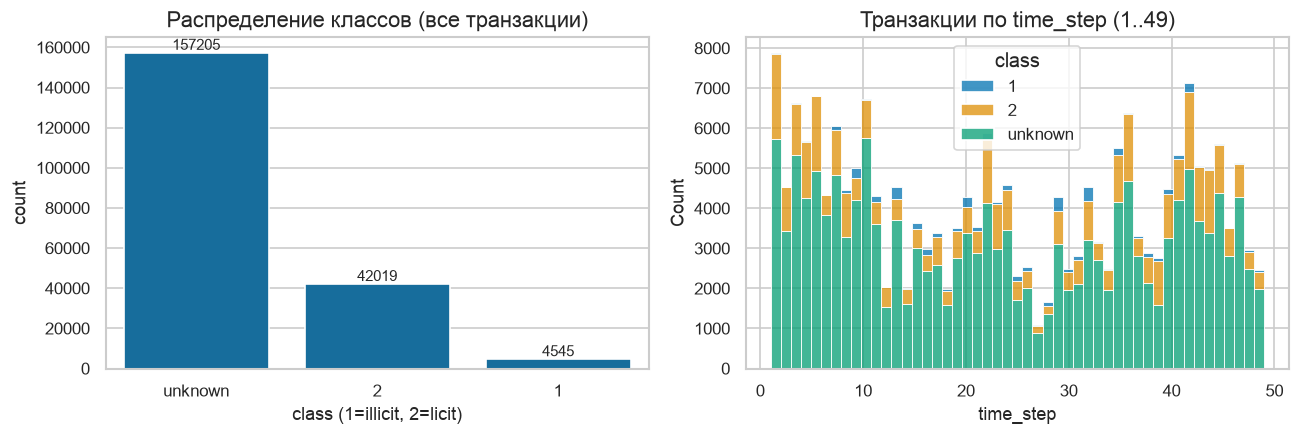

edges: 234,355, unique tx: 203,769


In [4]:
features, classes, edgelist, merged = load_elliptic(DATA_ROOT)

print(f"features: {features.shape}  (txId, time_step, 165 признаков)")
print(f"classes:  {classes.shape}")
print(f"edgelist: {edgelist.shape}")
print(f"merged:   {merged.shape}")

display(merged.head(3))
display(classes["class"].value_counts(dropna=False))
display(merged["time_step"].describe().to_frame().T)

# class distribution — overall
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sns.countplot(data=merged, x="class", order=["unknown", "2", "1"], ax=axes[0])
axes[0].set_title("Распределение классов (все транзакции)")
axes[0].set_xlabel("class (1=illicit, 2=licit)")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d", fontsize=9)

# by time_step (stacked by class)
ct = merged.groupby(["time_step", "class"]).size().reset_index(name="n")
sns.histplot(data=merged, x="time_step", hue="class", hue_order=["1", "2", "unknown"], multiple="stack", bins=49, ax=axes[1])
axes[1].set_title("Транзакции по time_step (1..49)")
axes[1].set_xlabel("time_step")
plt.tight_layout()
plt.show()

# quick edgelist sanity
print(f"edges: {len(edgelist):,}, unique tx: {merged['txId'].nunique():,}")


## 2. EDA — признаки и дисбаланс
Смотрим на несколько признаков, корреляции и долю illicit.


illicit: 4,545 / 203,769 = 2.23%
licit:   42,019 / 203,769 = 20.62%
unknown: 157,205 / 203,769 = 77.15%
среди labeled: illicit 9.76%  (4545/46564)
признаков: 165  ->  ['feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6'] ...


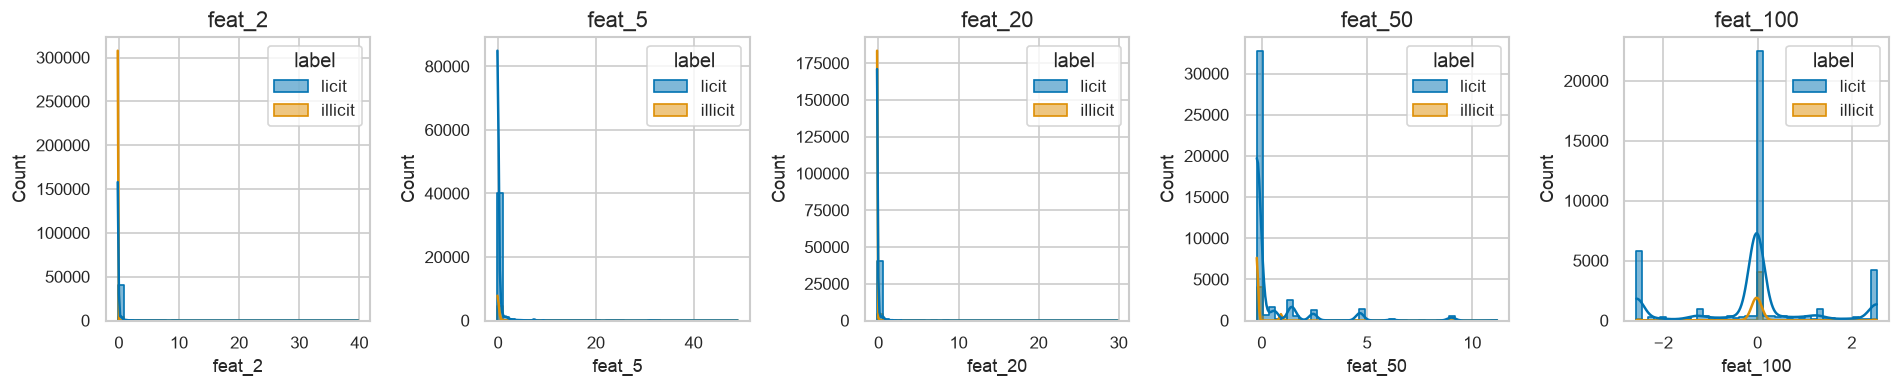

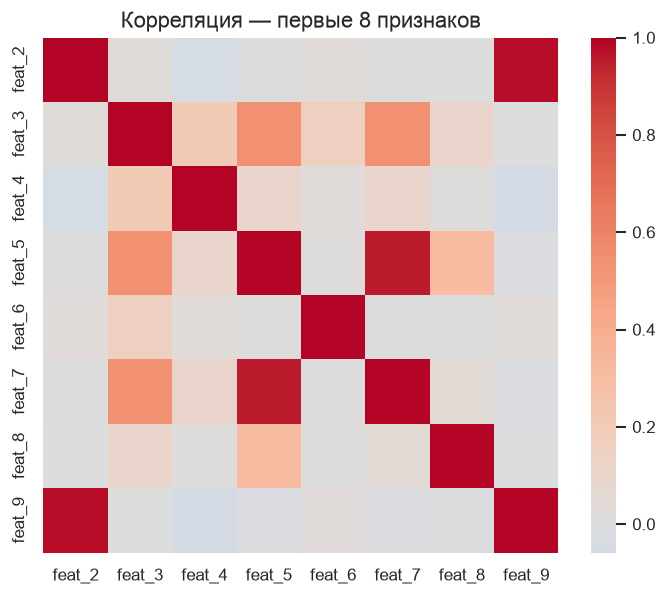

In [5]:
# imbalance check
total = len(merged)
labeled_mask = merged["class"].astype(str).isin(["1", "2"])
n_illicit = (merged["class"].astype(str) == "1").sum()
n_licit = (merged["class"].astype(str) == "2").sum()
n_unknown = (merged["class"].astype(str) == "unknown").sum()
print(f"illicit: {n_illicit:,} / {total:,} = {n_illicit/total:.2%}")
print(f"licit:   {n_licit:,} / {total:,} = {n_licit/total:.2%}")
print(f"unknown: {n_unknown:,} / {total:,} = {n_unknown/total:.2%}")
print(f"среди labeled: illicit {n_illicit/(n_illicit+n_licit):.2%}  ({n_illicit}/{n_illicit+n_licit})")

feat_cols_all = [c for c in merged.columns if c.startswith("feat_")]
print(f"признаков: {len(feat_cols_all)}  ->  {feat_cols_all[:5]} ...")

# 4-5 histograms with hue by class (only labeled for contrast)
sample_feats = ["feat_2", "feat_5", "feat_20", "feat_50", "feat_100"]
# ensure they exist
sample_feats = [c for c in sample_feats if c in feat_cols_all][:5]
labeled_df = merged[labeled_mask].copy()
labeled_df["label"] = (labeled_df["class"].astype(str) == "1").map({True: "illicit", False: "licit"})

fig, axes = plt.subplots(1, len(sample_feats), figsize=(3.2*len(sample_feats), 3.4), sharey=False)
if len(sample_feats) == 1:
    axes = [axes]
for ax, col in zip(axes, sample_feats):
    sns.histplot(data=labeled_df, x=col, hue="label", bins=40, element="step", kde=True, ax=ax, alpha=0.5)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# correlation matrix of small subset (first 8 + time_step)
corr_cols = feat_cols_all[:8]
corr = merged[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, ax=ax)
ax.set_title("Корреляция — первые 8 признаков")
plt.tight_layout()
plt.show()


## 3. Подготовка данных
Фильтруем только размеченные транзакции, формируем `X / y`, делаем temporal split 1..30 / 31..40 / 41..49 и масштабируем по train.


In [6]:
# filter labeled only
df = merged[merged["class"].astype(str).isin(["1", "2"])].copy()
df["y"] = (df["class"].astype(str) == "1").astype(int)

feat_cols = [c for c in df.columns if c.startswith("feat_")]
X_all = df[feat_cols]
y_all = df["y"]

train_df, valid_df, test_df = temporal_split(df, train_end=30, valid_end=40)

print(f"train: {len(train_df):,}  time 1..30   illicit {train_df['y'].mean():.2%}")
print(f"valid: {len(valid_df):,}  time 31..40  illicit {valid_df['y'].mean():.2%}")
print(f"test:  {len(test_df):,}  time 41..49  illicit {test_df['y'].mean():.2%}")

# StandardScaler fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feat_cols])
X_valid = scaler.transform(valid_df[feat_cols])
X_test = scaler.transform(test_df[feat_cols])
y_train, y_valid, y_test = train_df["y"].values, valid_df["y"].values, test_df["y"].values

print(f"X_train {X_train.shape}, X_valid {X_valid.shape}, X_test {X_test.shape}")


train: 26,905  time 1..30   illicit 10.98%
valid: 9,686  time 31..40  illicit 11.02%
test:  9,973  time 41..49  illicit 5.25%
X_train (26905, 165), X_valid (9686, 165), X_test (9973, 165)


## 4. Модели
Логистическая регрессия (LogReg) и случайный лес (random forest), оба с `class_weight=balanced`. Обучение только на train, без тюна на valid.


In [7]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, n_jobs=None)
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=72)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("обучено: LogisticRegression, RandomForest(n=200)")


обучено: LogisticRegression, RandomForest(n=200)


## 5. Оценка на test
PR-AUC, ROC-AUC, classification report, confusion matrix, PR- и ROC-кривые через `_theme`. `base_rate` — доля illicit в test.


base_rate (test illicit rate) = 0.0525

============ valid ============

LogReg — PR-AUC=0.3824  ROC-AUC=0.8851  base=0.1102
              precision    recall  f1-score   support

       licit      0.995     0.644     0.782      8619
     illicit      0.253     0.976     0.402      1067

    accuracy                          0.680      9686
   macro avg      0.624     0.810     0.592      9686
weighted avg      0.914     0.680     0.740      9686


RandForest — PR-AUC=0.9573  ROC-AUC=0.9861  base=0.1102
              precision    recall  f1-score   support

       licit      0.989     0.996     0.992      8619
     illicit      0.963     0.913     0.937      1067

    accuracy                          0.987      9686
   macro avg      0.976     0.954     0.965      9686
weighted avg      0.986     0.987     0.986      9686


============ test ============

LogReg — PR-AUC=0.1498  ROC-AUC=0.8211  base=0.0525
              precision    recall  f1-score   support

       licit      0.992 

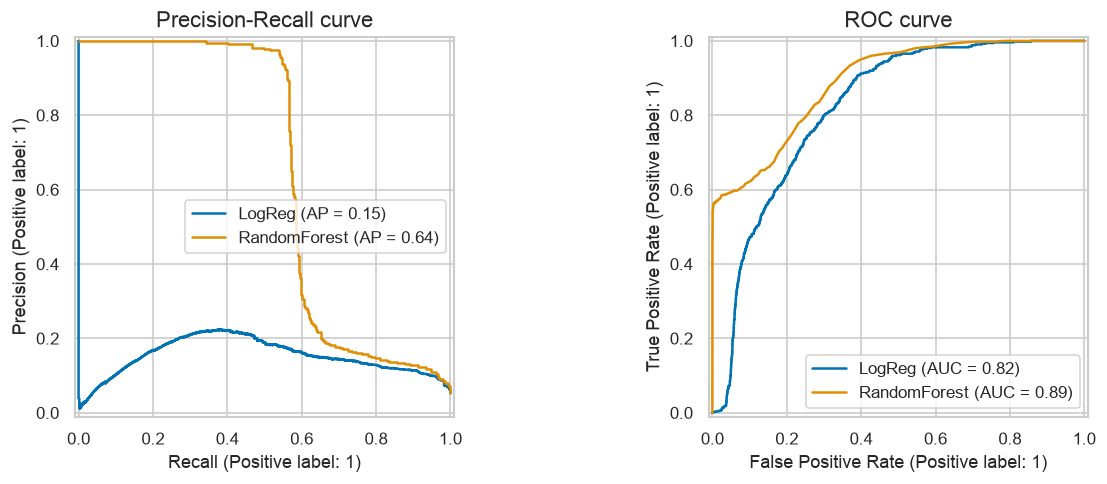

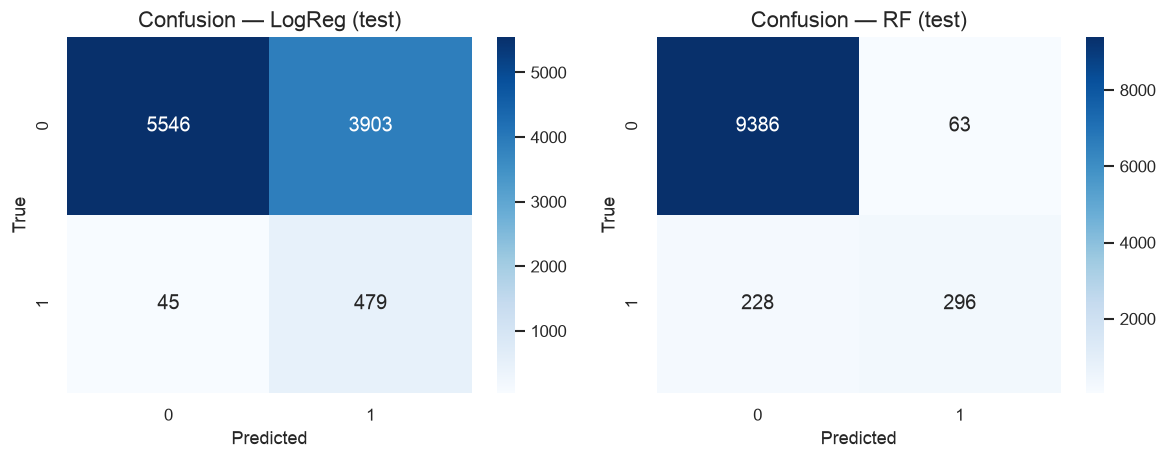

In [8]:
from sklearn.metrics import confusion_matrix as _cm

base_rate = y_test.mean()
print(f"base_rate (test illicit rate) = {base_rate:.4f}")

def evaluate(name, model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    pr_auc = average_precision_score(y, proba)
    roc_auc = roc_auc_score(y, proba)
    print(f"\n{name} — PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  base={y.mean():.4f}")
    print(classification_report(y, pred, target_names=["licit", "illicit"], digits=3))
    return proba, pred

for split_name, X, y in [("valid", X_valid, y_valid), ("test", X_test, y_test)]:
    print(f"\n{'='*12} {split_name} {'='*12}")
    lr_proba, lr_pred = evaluate("LogReg", lr, X, y)
    rf_proba, rf_pred = evaluate("RandForest", rf, X, y)

# test curves — focus on test, using _theme plotters
lr_test_proba = lr.predict_proba(X_test)[:, 1]
rf_test_proba = rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_pr_curve(y_test, lr_test_proba, ax=axes[0], label="LogReg")
plot_pr_curve(y_test, rf_test_proba, ax=axes[0], label="RandomForest")
axes[0].legend()

plot_roc_curve(y_test, lr_test_proba, ax=axes[1], label="LogReg")
plot_roc_curve(y_test, rf_test_proba, ax=axes[1], label="RandomForest")
axes[1].legend()
plt.tight_layout()
plt.show()

# confusion matrices (test)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_test, lr.predict(X_test), ax=axes[0])
axes[0].set_title("Confusion — LogReg (test)")
plot_confusion(y_test, rf.predict(X_test), ax=axes[1])
axes[1].set_title("Confusion — RF (test)")
plt.tight_layout()
plt.show()


## 6. Выводы

Что здесь принципиально, независимо от конкретных цифр прогона:

- Baseline обучается только на 165 признаках без графа; разбиение по времени исключает утечку будущего — это общее правило для всех ноутбуков серии.
- Дисбаланс сильный: illicit ~2.2% от всех транзакций (~9.8% среди размеченных), поэтому главная метрика — PR-AUC, а accuracy здесь неинформативна.
- Сравнивайте PR-AUC с `base_rate` (доля illicit в test): модель имеет смысл, только если заметно выше.
- Ожидаемая картина: на valid метрики высокие, на test проседают — доля illicit падает с ~11% в train до ~5% в test; это дрифт, а не баг. LogReg и RF различаются нелинейностью; кто выше на этом сплите — смотрите в выводе ячеек выше.
- Главный резерв качества — графовый контекст: следующий ноутбук (`02`) добавляет степени и PageRank к тем же 165 признакам.


## 7. Сохранение (опционально)
Модели лёгкие — можно сохранить для повторного использования. Раскомментируйте при необходимости.


In [ ]:
import pickle
from pathlib import Path

# ponytail: no versioning / registry, just pickle for local reuse; upgrade -> mlflow / joblib + hash
out_dir = Path("../../models") if Path("../../models").exists() or True else Path("models")
# try candidates similar to DATA_ROOT
for p in [Path("../../models"), Path("../models"), Path("models")]:
    try:
        p.mkdir(parents=True, exist_ok=True)
        out_dir = p
        break
    except Exception:
        continue

# pickle.dump({"scaler": scaler, "lr": lr, "rf": rf, "feat_cols": feat_cols}, open(out_dir / "baseline_tabular.pkl", "wb"))
# print(f"saved -> {out_dir / 'baseline_tabular.pkl'}")
print(f"ready to save -> {out_dir.resolve() / 'baseline_tabular.pkl'}  (раскомментируйте dump выше)")
